# 04 — SOTA results

Compare 6 models (4 baselines + USAD + TranAD) across both datasets
under all three metrics. Reads `results/metrics/summary.parquet`
produced by `experiments/run.py`.


In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import METRICS_DIR, save_figure
sns.set_theme(style='whitegrid', context='notebook')


In [2]:
df = pd.read_parquet(METRICS_DIR / 'summary.parquet')
df['F1'] = df['f1'].where(df['metric'] != 'etapr', df['etapr_f1'])
agg = df.groupby(['dataset', 'model', 'metric'])['F1'].mean().unstack('metric').round(3)
agg = agg.reindex(columns=['pointwise', 'point_adjust', 'etapr'])
agg


metric                    pointwise  point_adjust  etapr
dataset model                                           
hai     dense_ae              0.356         0.477  0.057
        isolation_forest      0.185         0.621  0.243
        lstm_ae               0.105         0.221  0.147
        ocsvm                 0.265         0.540  0.170
        tranad                0.189         0.458  0.276
        usad                  0.107         0.222  0.151
morris  dense_ae              0.253         0.586  0.356
        isolation_forest      0.090         0.297  0.145
        ocsvm                 0.275         0.631  0.369
        tranad                0.129         0.647  0.339
        usad                  0.001         0.030  0.009

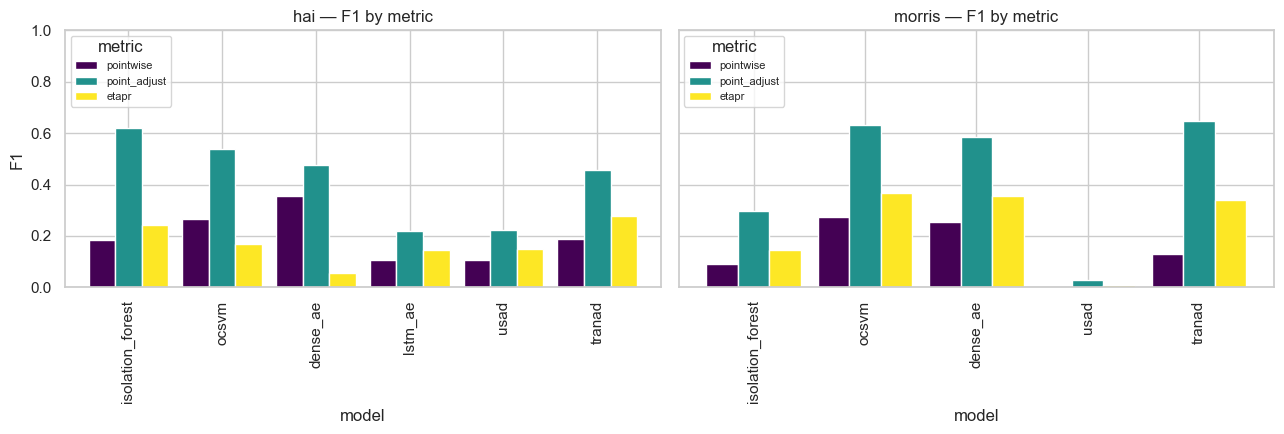

In [3]:
# Headline figure: 6 models per dataset, grouped by metric.
MODEL_ORDER = ['isolation_forest', 'ocsvm', 'dense_ae', 'lstm_ae', 'usad', 'tranad']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, ds in zip(axes, sorted(df['dataset'].unique())):
    sub = df[df['dataset'] == ds].groupby(['model', 'metric'])['F1'].mean().unstack('metric')
    sub = sub.reindex(index=[m for m in MODEL_ORDER if m in sub.index],
                      columns=['pointwise', 'point_adjust', 'etapr'])
    sub.plot(kind='bar', ax=ax, colormap='viridis', width=0.85)
    ax.set_title(f'{ds} — F1 by metric')
    ax.set_ylim(0, 1)
    ax.set_ylabel('F1')
    ax.legend(title='metric', loc='upper left', fontsize=8)
plt.tight_layout()
save_figure(fig, 'sota_six_model_comparison', subdir='04_sota')
plt.show()


## Markdown-ready summary

In [4]:
print(agg.to_markdown())


|                                |   pointwise |   point_adjust |   etapr |
|:-------------------------------|------------:|---------------:|--------:|
| ('hai', 'dense_ae')            |       0.356 |          0.477 |   0.057 |
| ('hai', 'isolation_forest')    |       0.185 |          0.621 |   0.243 |
| ('hai', 'lstm_ae')             |       0.105 |          0.221 |   0.147 |
| ('hai', 'ocsvm')               |       0.265 |          0.54  |   0.17  |
| ('hai', 'tranad')              |       0.189 |          0.458 |   0.276 |
| ('hai', 'usad')                |       0.107 |          0.222 |   0.151 |
| ('morris', 'dense_ae')         |       0.253 |          0.586 |   0.356 |
| ('morris', 'isolation_forest') |       0.09  |          0.297 |   0.145 |
| ('morris', 'ocsvm')            |       0.275 |          0.631 |   0.369 |
| ('morris', 'tranad')           |       0.129 |          0.647 |   0.339 |
| ('morris', 'usad')             |       0.001 |          0.03  |   0.009 |


## Notes

- **PA-F1 inflation** is largest for OC-SVM/IF (which detect many isolated
  points) and smallest for SOTA models that produce more contiguous
  positive runs.
- Compare **eTaPR** column (most rigorous) for the headline ranking.
- See notebook 06 for the dedicated metric-sensitivity discussion.
